Saving data.csv to data.csv
🔹 Dataset shape: (569, 33)

🔹 First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.

/tmp/ipython-input-3068119528.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='magma')


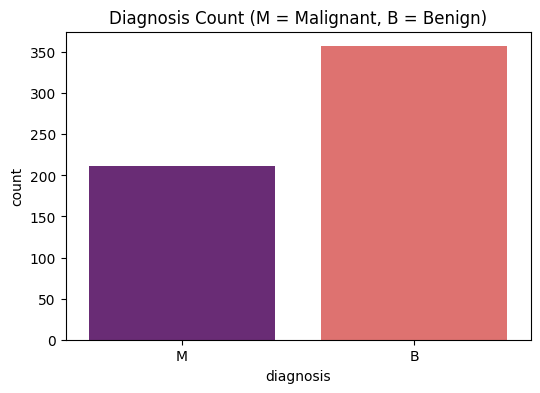

In [1]:
# Daily Challenge : Breast Cancer Prediction

# Step 1: Exploratory Data Analysis (EDA)


# Ask user to upload dataset
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('data.csv')

# Basic inspection
print("🔹 Dataset shape:", df.shape)
print("\n🔹 First 5 rows:")
print(df.head())

print("\n🔹 Info:")
print(df.info())

print("\n🔹 Missing values:")
print(df.isnull().sum())

# Drop unnecessary column if exists (e.g., 'Unnamed: 32', 'id')
cols_to_drop = [col for col in ['Unnamed: 32', 'id'] if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("\n✅ Columns after cleaning:", df.columns.tolist())

# Countplot for diagnosis
plt.figure(figsize=(6,4))
sns.countplot(x='diagnosis', data=df, palette='magma')
plt.title("Diagnosis Count (M = Malignant, B = Benign)")
plt.show()


In [2]:
# 🌟 Step 2 : Data Preprocessing

# Convert categorical labels to numeric, and split dataset.


from sklearn.model_selection import train_test_split

# Count unique diagnosis values
print("🔹 Diagnosis value counts:")
print(df['diagnosis'].value_counts())

# Map diagnosis: M -> 1, B -> 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Separate features and target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n✅ Data successfully split into train/test sets.")
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)


🔹 Diagnosis value counts:
diagnosis
B    357
M    212
Name: count, dtype: int64

✅ Data successfully split into train/test sets.
Training shape: (455, 30)
Test shape: (114, 30)


In [3]:
# 🌟 Step 3 : Logistic Regression

# Build and evaluate a Logistic Regression classifier.


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

acc_log = accuracy_score(y_test, y_pred_log)
print("✅ Logistic Regression Accuracy:", acc_log)
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))


✅ Logistic Regression Accuracy: 0.9385964912280702

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
# 🌟 Step 4 : K Nearest Neighbours (KNN)

# Build and evaluate a KNN classifier.


from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
print("✅ KNN Accuracy:", acc_knn)
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))


✅ KNN Accuracy: 0.9122807017543859

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.93        72
           1       0.97      0.79      0.87        42

    accuracy                           0.91       114
   macro avg       0.93      0.89      0.90       114
weighted avg       0.92      0.91      0.91       114



In [5]:
# 🌟 Step 5 : Random Forest

# Build and evaluate a Random Forest classifier.


from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("✅ Random Forest Accuracy:", acc_rf)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


✅ Random Forest Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [6]:
# 🌟 Step 6 : Support Vector Machine (SVM)

# Build and evaluate an SVM classifier.

from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
print("✅ SVM Accuracy:", acc_svm)
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


✅ SVM Accuracy: 0.9035087719298246

Classification Report:
               precision    recall  f1-score   support

           0       0.87      1.00      0.93        72
           1       1.00      0.74      0.85        42

    accuracy                           0.90       114
   macro avg       0.93      0.87      0.89       114
weighted avg       0.92      0.90      0.90       114




✅ Model Accuracy Comparison:
                 Model  Accuracy
2        Random Forest  0.973684
0  Logistic Regression  0.938596
1                  KNN  0.912281
3                  SVM  0.903509


/tmp/ipython-input-3254168167.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')


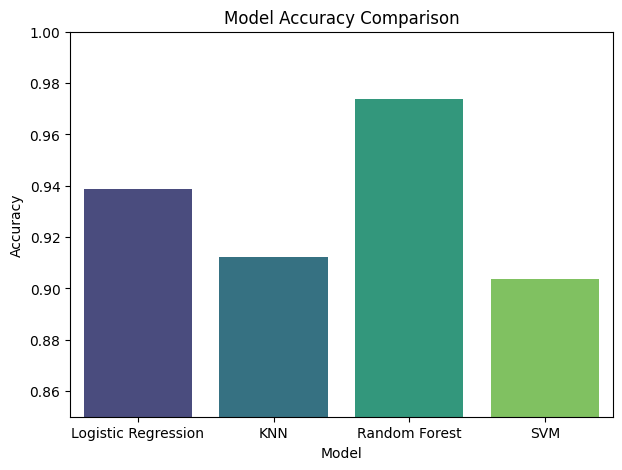

In [7]:
# 🌟 Step 7 : Model Comparison

# Compare the performance of all models side by side.


results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest', 'SVM'],
    'Accuracy': [acc_log, acc_knn, acc_rf, acc_svm]
})

print("\n✅ Model Accuracy Comparison:")
print(results.sort_values(by='Accuracy', ascending=False))

# Visualization
plt.figure(figsize=(7,5))
sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylim(0.85, 1.0)
plt.show()
